In [1]:
import Agents

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
NA = 100
NB = 1
N = NA+NB

initialize_money = 'set'
M = 100.

n = 2

QA1 = 1.
QA2 = 0.

QB1 = 0.
QB2 = 0.

QA_0 = np.array([QA1, QA2])
QB_0 = np.array([QB1, QB2])

QA = np.copy(QA_0)
QB = np.copy(QB_0)

qA = np.array([0, 0])
qB = np.array([0, 0])

cA = np.array([0, 0])
cB = np.array([200., 0])

DA = cA.copy()
DB = cB.copy()

initialize_prices = 'set'

p1buy_A_0    = 0. 
p1sell_A_0   = 1.

p2buy_A_0    = 0.
p2sell_A_0   = 0. 

p1buy_B_0    = 1.
p1sell_B_0   = 0. 

p2buy_B_0    = 0.
p2sell_B_0   = 0.

In [3]:
agentA_list = [Agents.Agent(QA.copy(), DA.copy(), M, n_actions=1, input_dims=[1]) for v in range(NA)]
agentB_list = [Agents.Agent(QB.copy(), DB.copy(), M, n_actions=1, input_dims=[1]) for v in range(NB)]

agent_list = agentA_list + agentB_list

In [4]:
# Initialize agent asking and bidding prices

In [5]:
for agent in agentA_list:

    if initialize_prices=='random':

        agent.p_buy  = np.random.uniform(agent.M, size=n)
        agent.p_sell = np.random.uniform(agent.M, size=n)

    else:
        agent.p_buy  = [p1buy_A_0, p2buy_A_0]
        agent.p_sell = [p1sell_A_0, p2sell_A_0]
        
for agent in agentB_list:

    if initialize_prices=='random':

        agent.p_buy  = np.random.uniform(agent.M, size=n)
        agent.p_sell = np.random.uniform(agent.M, size=n)

    else:
        agent.p_buy  = [p1buy_B_0, p2buy_B_0]
        agent.p_sell = [p1sell_B_0, p2sell_B_0]

In [6]:
### Simple Continuous Double Auction ###

In [7]:
def determine_market_quantity(agent):
    S = agent.Q - agent.D

    scaling_mask = S > 0
    S[scaling_mask] = gamma*S[scaling_mask]

    return S

def softmax(X):
    
    prob = np.exp(X)/(np.exp(X).sum())
    
    return prob

def transaction(i, buyer_agent, buyer_index, seller_agent, seller_index):

    S_buyer   = -agent_data[buyer_index, 2, i]
    buyer_bid  = agent_data[buyer_index, 0, i]
    buyer_M = agent_Mdata[buyer_index]
    
    # Check that the buyer has enough money to purchase S_buyer, else 
    if buyer_bid*S_buyer > buyer_M:
        S_buyer = buyer_M/buyer_bid
    
    S_seller   = agent_data[seller_index, 2, i]
    seller_ask = agent_data[seller_index, 1, i]
    
    # Come to agreement
    # Can't buy more than the seller has, or the buyer wants
    S_exchanged = min(S_buyer, S_seller)
    # Select random price between the bidding and asking price.
    p_exchanged = random.uniform(seller_ask, buyer_bid)
    dM_exchanged = p_exchanged * S_exchanged
    # Since the bidding price is larger than the asking price, then p_exchanged*S_exchanged will still <= buyer M

    # Update the agents' states
    buyer_agent.Q[i]  = buyer_agent.Q[i]  + S_exchanged
    seller_agent.Q[i] = seller_agent.Q[i] - S_exchanged

    buyer_agent.M  = buyer_agent.M  - dM_exchanged
    seller_agent.M = seller_agent.M + dM_exchanged


    # Update the agent_data numpy array
    agent_data[buyer_index,  2, i] += S_exchanged
    agent_data[seller_index, 2, i] -= S_exchanged
    
    agent_Mdata[buyer_index]  = buyer_agent.M
    agent_Mdata[seller_index] = seller_agent.M
    
    return p_exchanged, S_exchanged, S_exchanged/S_buyer, S_exchanged/S_seller # S_buyer will be adjusted if they don't have the money


In [8]:
def update_prices(i, buyer_index, seller_index, transaction_successful):

    delta_bidding_price = np.random.uniform(0, [bidding_theta]*Nm)
    delta_asking_price  = np.random.uniform(0, [asking_theta]*Nm)    

    if transaction_successful:

        #### Buyers ####
        # The selected buyer will adjust their bid accordingly
        # The buyer has bought all they want in the market. Next round, they will decrease their bid
        if buyer_eff == 1.0: 
            agent_data[buyer_index, 0, i] *= (1.0 - delta_bidding_price[buyer_index])

        # The buyer has not bought all they want in the market. Next round, they will increase their bid
        elif buyer_eff < 1.0: 
            agent_data[buyer_index, 0, i] *=  (1.0 + delta_bidding_price[buyer_index])

        # The non selected buyers will increase their bids
        non_selected_buyers_mask = buyers_mask
        non_selected_buyers_mask[buyer_index] = False # This will update the buyers_mask array
        agent_data[non_selected_buyers_mask, 0, i] *= (1.0 + delta_bidding_price[non_selected_buyers_mask])

        #### Sellers ####
        # The selected seller will adjust their ask accordingly
        # The seller has sold all they want in the market. Next round, they will increase their ask
        if seller_eff == 1.0: 
            agent_data[seller_index, 1, i] *= (1.0 + delta_asking_price[seller_index])

        # The seller has not sold all they want in the market. Next round, they will decrease their ask
        if seller_eff < 1.0:
            agent_data[seller_index, 1, i] *= (1.0 - delta_asking_price[seller_index])

        # The non selected sellers will decrease their asks
        non_selected_sellers_mask = sellers_mask
        non_selected_sellers_mask[seller_index] = False # This will update the sellers_mask array
        agent_data[non_selected_sellers_mask, 1, i] *= (1.0 - delta_asking_price[non_selected_sellers_mask])

    else:

        #### Buyers ####
        # No transaction occurs, so all buyers will increase prices
        agent_data[buyers_mask, 0, i] *= (1.0 + delta_bidding_price[buyers_mask])

        #### Sellers ####
        # No transaction occurs, so all selelrs will decrease their prices
        agent_data[sellers_mask, 0, i] *= (1.0 - delta_asking_price[sellers_mask])

    

In [9]:
Nproducts = n #2
max_tries = 100

ExchangeDict = {agent : 2 for agent in agent_list}

# Number of agents in the market
Nm = len(ExchangeDict)

M_min = 0.01 # Agent exists market if their money amount is less than this
gamma = 1
assert gamma <= 1

theta = 0.1 # [0, inf) Max proportional increase/decrease in prices
assert theta >= 0

bidding_theta = theta 
asking_theta = theta

# Create list of agents in market
exchanging_agent_list = np.array([agent for agent in ExchangeDict.keys()])
agent_mapping = {agent_obj: i for i,agent_obj in enumerate(ExchangeDict.keys())}

# Create numpy array of agent data
agent_data = np.array([[agent.p_buy, agent.p_sell, determine_market_quantity(agent)] for agent in ExchangeDict.keys()]) # prices and quantity per commodity
agent_Mdata = np.array([agent.M for agent in ExchangeDict.keys()]) # Money

uncleared_commodities = list(range(Nproducts))



In [10]:
#agent_data, uncleared_commodities

In [11]:
trial_data = []
trial_Mdata = []
trial_buyer = []
trial_seller = []
trial_price = []
n_tries = 0

trial_data.append(agent_data.copy())

In [12]:
while (len(uncleared_commodities) > 0) and (n_tries < max_tries):
    
    #print()
    #print(n_tries)

    # For trial, pick random commodity
    i = random.choice(uncleared_commodities) # commodity i

    agent_data_i = agent_data[:,:,i]

    # Create mask for buyers and select their data
    # Eligible buyers have a negative surplus, and have money to spend
    buyers_mask = (agent_data_i[:, 2] < 0) & (agent_Mdata > M_min)
    buyers_data_i = agent_data_i[buyers_mask]

    # Creat mask for sellers and select their data
    sellers_mask = agent_data_i[:, 2] > 0
    sellers_data_i = agent_data_i[sellers_mask]
    
    # If there are no buyers or sellers for commodity i, then this commodity is cleared
    if (buyers_mask.sum() == 0) or (sellers_mask.sum() == 0):
        uncleared_commodities.remove(i)
        
    else:
        # Continue with commodity

        # Using the bidding and asking prices, select a buyer, seller pair for this trial
        # The buyers, sellers are selected with probabilities related to their prices. Use softmax for this
        bidding_prices_i = buyers_data_i[:,0]
        asking_prices_i  = sellers_data_i[:,1]
        softmax_bids = scipy.special.softmax(bidding_prices_i) #scipy function avoids overflow errors
        softmax_asks = scipy.special.softmax(-asking_prices_i)

        buyer_agent  = np.random.choice(exchanging_agent_list[buyers_mask],  p=softmax_bids)
        buyer_index = agent_mapping[buyer_agent]

        seller_agent = np.random.choice(exchanging_agent_list[sellers_mask], p=softmax_asks)
        seller_index = agent_mapping[seller_agent]

        # Check if the selected buyer and seller can make a transaction
        buyer_bid  = agent_data_i[buyer_index,  0]
        seller_ask = agent_data_i[seller_index, 1]

        if buyer_bid >= seller_ask:

            # Transaction
            #print('Transaction')
            p, S_exchanged, buyer_eff, seller_eff = transaction(i, buyer_agent, buyer_index, seller_agent, seller_index)
            transaction_successful = True

        else:
            # prices change?
            transaction_successful = False
            #print('No Transaction')

        update_prices(i, buyer_index, seller_index, transaction_successful)

        trial_data.append(agent_data.copy())
        trial_Mdata.append(agent_Mdata.copy())
        trial_buyer.append(buyer_index)
        trial_seller.append(seller_index)
        trial_price.append(p) # assuming all are for i = 0
        
        n_tries += 1
        
trial_data = np.array(trial_data)
trial_Mdata = np.array(trial_Mdata)

In [13]:
#softmax(bidding_prices_i)
scipy.special.softmax(bidding_prices_i)

array([1.])

In [14]:
uncleared_commodities

[]

In [15]:
n_tries, max_tries

(57, 100)

In [16]:
#trial_buyer

In [17]:
#trial_seller

In [18]:
#trial_price

In [19]:
#buyers_mask

In [20]:
#trial_data

In [21]:
#trial_data[:,:,:,0]

In [22]:
i = 0
asking_prices = trial_data[:, 0:NA, 1, i]
mean_asks = asking_prices.mean(axis=1)

supply = trial_data[:, 0:NA, 2, i]
total_supply = supply.sum(axis=1)

In [23]:
bidding_prices = trial_data[:, NA:NA+NB, 0, i]
mean_bids = bidding_prices.mean(axis=1)

demand = -trial_data[:, NA:NA+NB, 2, i]
total_demand = demand.sum(axis=1)

In [24]:
seller_money = trial_Mdata[:, 0:NA]
buyer_money = trial_Mdata[:, NA:NA+NB]
buyer_money2 = bidding_prices*demand

In [25]:
#[supply[t, trial_buyer[t]-NB] for t in range(len(trial_buyer))]

In [26]:
trial_buyer[0] - NA

0

In [27]:
buyer_bids = [bidding_prices[t, trial_buyer[t]-NA] for t in range(len(trial_buyer))]
buyer_demand = [demand[t, trial_buyer[t]-NA] for t in range(len(trial_buyer))]

In [28]:
seller_asks = [asking_prices[t, trial_seller[t]] for t in range(len(trial_seller))]
seller_supply = [supply[t, trial_seller[t]] for t in range(len(trial_seller))]

Even though there is only one buyer, they still increase their prices because they want 10, but only get 1 at each transaction (because each seller only has one item)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


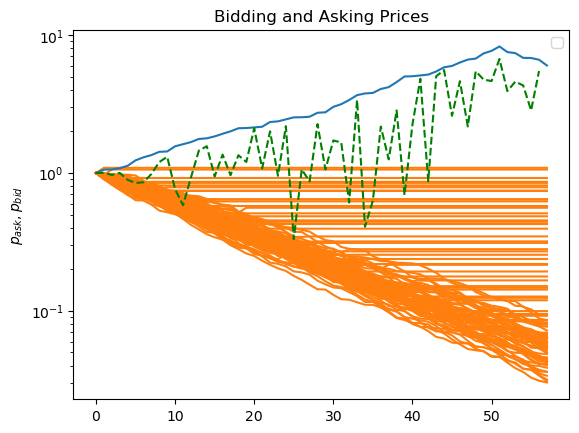

In [29]:
plt.plot(asking_prices, c='C1')
#plt.scatter(x=range(len(seller_asks)), y=seller_asks, c='C1', label='sellers')

plt.plot(bidding_prices, c='C0')
#plt.scatter(x=range(len(buyer_bids)), y=buyer_bids, c='C0', label='buyers')

plt.plot(trial_price, c='green', ls='--')
#plt.scatter(x=range(len(trial_price)), y=trial_price, c='green', label='settled price')

plt.ylabel('$p_{ask}, p_{bid}$')
plt.title('Bidding and Asking Prices')
plt.legend()

plt.yscale('log')

Text(0, 0.5, '$S^{\\sigma}$')

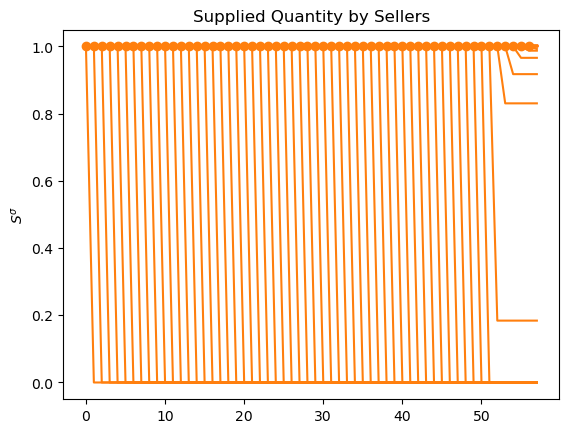

In [30]:
plt.plot(supply, c='C1')
plt.scatter(x=range(len(seller_supply)), y=seller_supply, c='C1')

plt.title('Supplied Quantity by Sellers')
plt.ylabel('$S^{\sigma}$')
#plt.yscale('log')

Text(0, 0.5, '$-S^{\\beta}$')

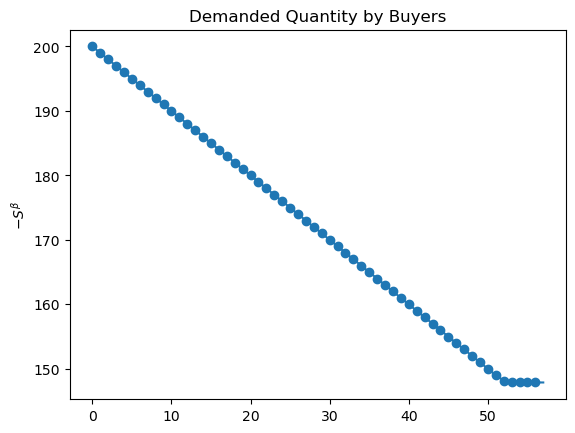

In [31]:
plt.plot(demand, c='C0')
plt.scatter(x=range(len(buyer_demand)), y=buyer_demand, c='C0')

plt.title('Demanded Quantity by Buyers')
plt.ylabel(r'$-S^{\beta}$')

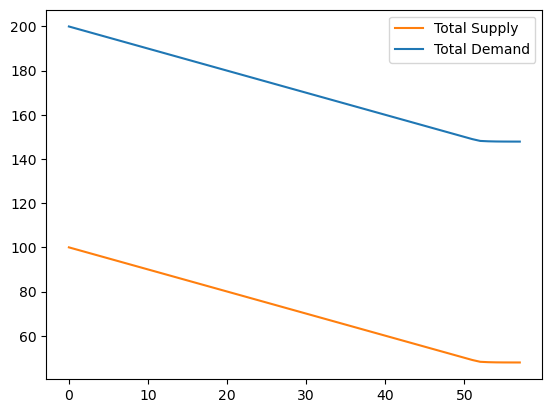

In [32]:
plt.plot(supply.sum(axis=1), c='C1', label='Total Supply')
plt.plot(demand.sum(axis=1), c='C0', label='Total Demand')
plt.legend()
#plt.yscale('log')

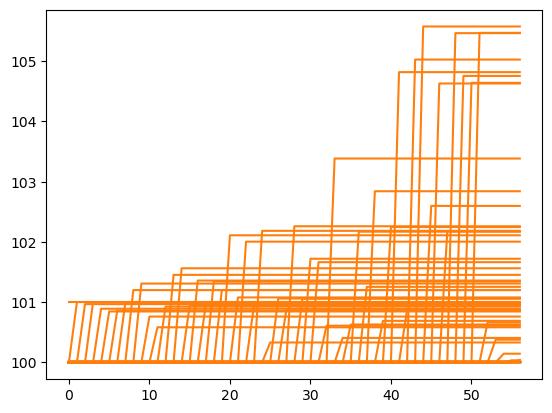

In [33]:
plt.plot(seller_money, c='C1')
plt.show()

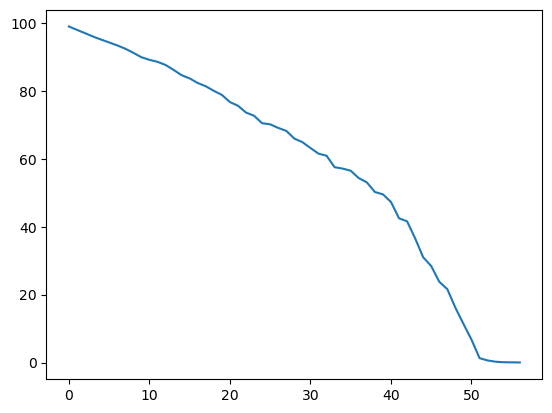

In [34]:
plt.plot(buyer_money, c='C0')
#plt.plot(buyer_money2, c='g', ls=':')
plt.show()

In [35]:
#[plt.plot(buyer_money[:,n], buyer_money2[:-1,n]) for n in range(NB)]
#plt.show()

In [36]:
#buyer_money[:,n], buyer_money2[:-1,n]

Text(0, 0.5, '$p_{ask}$')

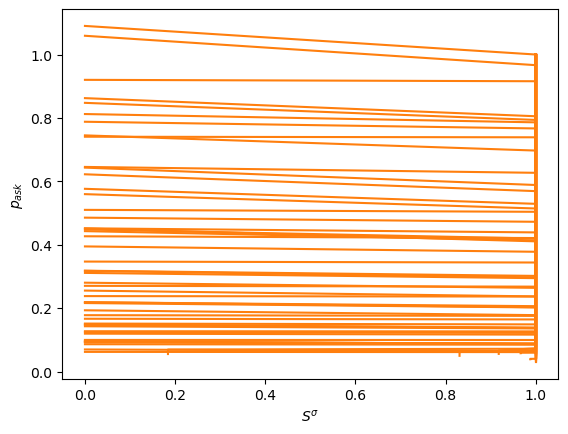

In [37]:
plt.plot(supply, asking_prices, c='C1')
plt.xlabel('$S^{\sigma}$')
plt.ylabel('$p_{ask}$')

Text(0, 0.5, '$p_{bid}$')

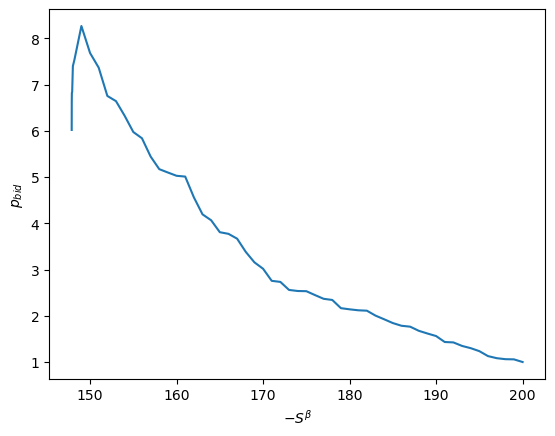

In [38]:
plt.plot(demand, bidding_prices)#, c='C0')
plt.xlabel(r'$-S^{\beta}$')
plt.ylabel('$p_{bid}$')
#plt.xscale('log')
#plt.yscale('log')

Text(0, 0.5, 'Mean Asking Price')

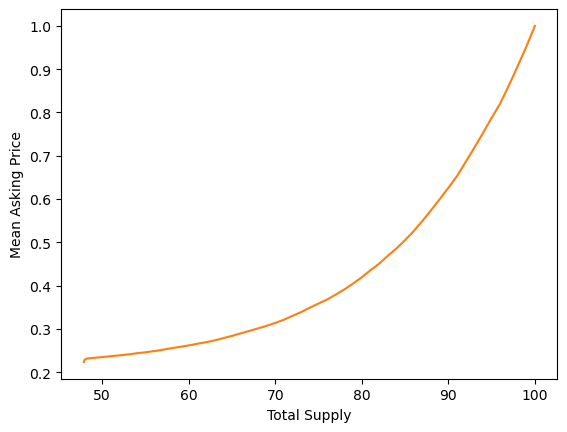

In [39]:
plt.plot(total_supply, mean_asks , c='C1')
plt.xlabel('Total Supply')
plt.ylabel('Mean Asking Price')

Text(0, 0.5, 'Mean Bidding Price')

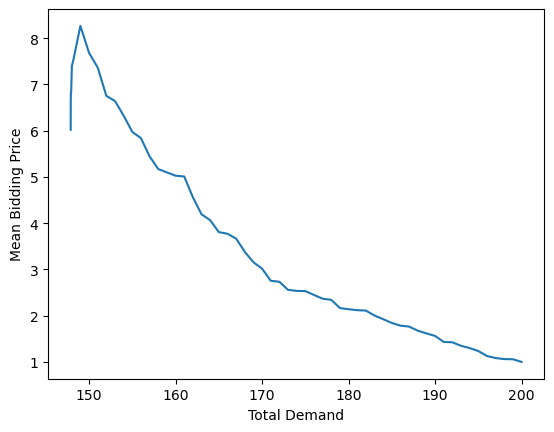

In [40]:
plt.plot(total_demand, mean_bids, c='C0')
plt.xlabel('Total Demand')
plt.ylabel('Mean Bidding Price')

Text(0, 0.5, '$p_{bid}$')

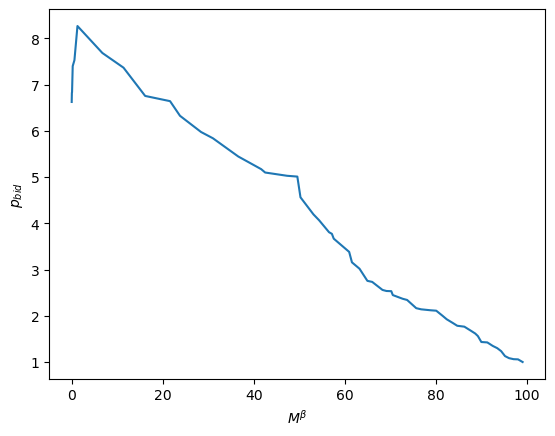

In [41]:
plt.plot(buyer_money, bidding_prices[:-1])#, c='C0')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel('$p_{bid}$')
#plt.xscale('log')
#plt.yscale('log')

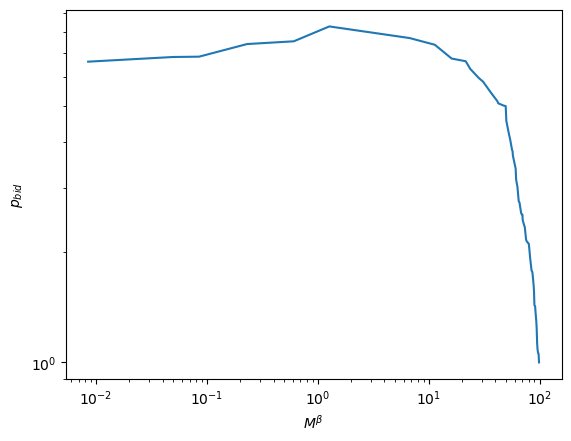

In [42]:
plt.plot(buyer_money, bidding_prices[:-1])#, c='C0')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel('$p_{bid}$')
plt.xscale('log')
plt.yscale('log')

In [43]:
buyer_money.shape, bidding_prices.shape

((57, 1), (58, 1))

In [44]:
for agent in agent_list:
    
    print(agent.Q)

[0. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0.91766649 0.        ]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[0.99249154 0.        ]
[0. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[0.83074481 0.        ]
[0. 0.]
[0.96618761 0.        ]
[1. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[0.18410072 0.        ]
[1. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[0.98749671 0.        ]
[0. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[1. 0.]
[0. 0.]
[1. 0.]
[52.12131212  0.        ]


In [45]:
for agent in agent_list:
    
    print(agent.p_buy)

[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]

In [46]:
agent_data

array([[[ 0.00000000e+00,  0.00000000e+00],
        [ 2.16006693e-01,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 3.38674583e-02,  0.00000000e+00],
        [ 1.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 4.51263523e-01,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 6.95917406e-02,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 8.01870238e-02,  0.00000000e+00],
        [ 1.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 5.59567373e-01,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 4.12462404e-02,  0.00000000e+00],
        [ 1.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00],
        [ 3.175828

In [47]:
agent_Mdata

array([1.02170335e+02, 1.00000000e+02, 1.01359344e+02, 1.04754562e+02,
       1.00000000e+02, 1.01345005e+02, 1.00000000e+02, 1.00868972e+02,
       1.00000000e+02, 1.00000000e+02, 1.00378064e+02, 1.05464524e+02,
       1.00856593e+02, 1.01309470e+02, 1.01721331e+02, 1.01060190e+02,
       1.00000000e+02, 1.00944073e+02, 1.02004684e+02, 1.01453785e+02,
       1.02110407e+02, 1.02184518e+02, 1.01664360e+02, 1.00000000e+02,
       1.00584062e+02, 1.01200907e+02, 1.00000000e+02, 1.00000000e+02,
       1.01079365e+02, 1.00000000e+02, 1.01000000e+02, 1.02260437e+02,
       1.00000000e+02, 1.01563096e+02, 1.00000000e+02, 1.00846439e+02,
       1.00690420e+02, 1.00630268e+02, 1.00000000e+02, 1.00891393e+02,
       1.00968202e+02, 1.00928235e+02, 1.00871785e+02, 1.00000000e+02,
       1.00000000e+02, 1.05026154e+02, 1.00041199e+02, 1.00610511e+02,
       1.00000000e+02, 1.00000000e+02, 1.00000000e+02, 1.00000000e+02,
       1.02176535e+02, 1.00982856e+02, 1.04629331e+02, 1.01000851e+02,
      